# RaksaDana — LSTM Modelling & Evaluation


## Setup

In [35]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ks_2samp
from statsmodels.stats.diagnostic import acorr_ljungbox

import mlflow
import mlflow.tensorflow

warnings.filterwarnings('ignore')

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

ROOT          = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DIR = os.path.join(ROOT, 'data', 'processed')
MODEL_DIR     = os.path.join(ROOT, 'models')
MLFLOW_DB     = os.path.join(ROOT, 'mlflow.db')
os.makedirs(MODEL_DIR, exist_ok=True)

mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB}')
mlflow.set_experiment('RaksaDana-LSTM-v2')

print(f'TensorFlow {tf.__version__}')
print(f'MLflow     {mlflow.__version__}')


TensorFlow 2.21.0
MLflow     3.12.0


## Data

In [36]:
with open(os.path.join(PROCESSED_DIR, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

sequences     = data['sequences']
scalers       = data['scalers']
feature_cols  = data['feature_cols']
target_col    = data['target_col']
target_idx    = data['target_idx']
window_size   = data['window_size']
tickers       = data['tickers']
featured_data = data['featured_data']

active_features = feature_cols
n_features      = len(feature_cols)

print(f'Tickers   : {tickers}')
print(f'Features  : {n_features} ({feature_cols})')
print(f'Target    : {target_col}')
print(f'Scaler    : {data.get("scaler_type", "?")} (fit: {data.get("scaler_fit", "?")})')
print(f'Window    : {window_size}')
for ticker in tickers:
    s = sequences[ticker]
    print(f'{ticker:10s}  X_train {s["X_train"].shape}  X_test {s["X_test"].shape}')


Tickers   : ['BBCA.JK', 'BBRI.JK', 'BMRI.JK']
Features  : 17 (['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA20', 'MA50', 'RSI', 'BB_upper', 'BB_lower', 'BB_width', 'Daily_Return', 'Log_Return', 'Volume_MA7', 'MACD', 'MACD_signal'])
Target    : Close
Scaler    : RobustScaler (fit: train_only)
Window    : 60
BBCA.JK     X_train (2090, 60, 17)  X_test (523, 60, 17)
BBRI.JK     X_train (2090, 60, 17)  X_test (523, 60, 17)
BMRI.JK     X_train (2090, 60, 17)  X_test (523, 60, 17)


## Model Architecture

In [37]:
def build_model(input_shape, units=32, dropout=0.30, rec_dropout=0.20,
                l2_reg=1e-4, lr=5e-4):
    model = Sequential([
        Bidirectional(
            LSTM(units, return_sequences=False,
                 recurrent_dropout=rec_dropout, kernel_regularizer=l2(l2_reg)),
            input_shape=input_shape,
        ),
        LayerNormalization(),
        Dropout(dropout),
        Dense(8, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(1),
    ])
    model.compile(optimizer=Adam(lr), loss='huber', metrics=['mae'])
    return model

build_model((window_size, n_features)).summary()


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_20                │ (None, 64)             │        12,800 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_20          │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,457 (52.57 KB)

 Trainable params: 13,457 (52.57 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [38]:
EPOCHS = 100
BATCH  = 32
SEEDS  = [42, 123, 7]

MODEL_PARAMS = {
    'units'      : 32,
    'dropout'    : 0.30,
    'rec_dropout': 0.20,
    'l2_reg'     : 1e-4,
    'lr'         : 5e-4,
}

def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=15,
                      restore_best_weights=True, start_from_epoch=10, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=7, min_lr=1e-6, verbose=0),
    ]

ensemble_models = {}
histories       = {}

for ticker in tickers:
    s = sequences[ticker]
    X_train, y_train = s['X_train'], s['y_train']

    val_split   = int(len(X_train) * 0.85)
    X_tr, X_val = X_train[:val_split], X_train[val_split:]
    y_tr, y_val = y_train[:val_split], y_train[val_split:]

    print(f'\n{ticker}')
    seed_models = []

    for seed in SEEDS:
        tf.random.set_seed(seed)
        np.random.seed(seed)

        model = build_model((window_size, n_features), **MODEL_PARAMS)

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=EPOCHS, batch_size=BATCH,
            callbacks=get_callbacks(),
            shuffle=False, verbose=0,
        )
        seed_models.append(model)
        print(f'  seed={seed:>4d}  epochs={len(history.history["loss"]):>3d}  '
              f'best_val_loss={min(history.history["val_loss"]):.5f}')

        if seed == SEEDS[0]:
            histories[ticker] = history.history

    ensemble_models[ticker] = seed_models
    seed_models[0].save(os.path.join(MODEL_DIR, f'lstm_{ticker.replace(".","_")}_best.keras'))

    with mlflow.start_run(run_name=ticker):
        mlflow.log_params({
            'ticker'       : ticker,
            'ensemble_size': len(SEEDS),
            'architecture' : 'BiLSTM',
            'scaler'       : data.get('scaler_type', '?'),
            'target'       : 'raw_close',
            'epochs'       : EPOCHS,
            'batch_size'   : BATCH,
            'window_size'  : window_size,
            'n_features'   : n_features,
            'loss'         : 'huber',
            'monitor'      : 'val_loss',
            'es_patience'  : 15,
            **MODEL_PARAMS,
        })



BBCA.JK
  seed=  42  epochs= 28  best_val_loss=0.12984
  seed= 123  epochs= 78  best_val_loss=0.08035
  seed=   7  epochs= 34  best_val_loss=0.07744

BBRI.JK
  seed=  42  epochs= 62  best_val_loss=0.10279
  seed= 123  epochs= 73  best_val_loss=0.10643
  seed=   7  epochs= 61  best_val_loss=0.08299

BMRI.JK
  seed=  42  epochs= 83  best_val_loss=0.82675
  seed= 123  epochs=100  best_val_loss=1.06120
  seed=   7  epochs= 48  best_val_loss=0.75536


## Training Curves

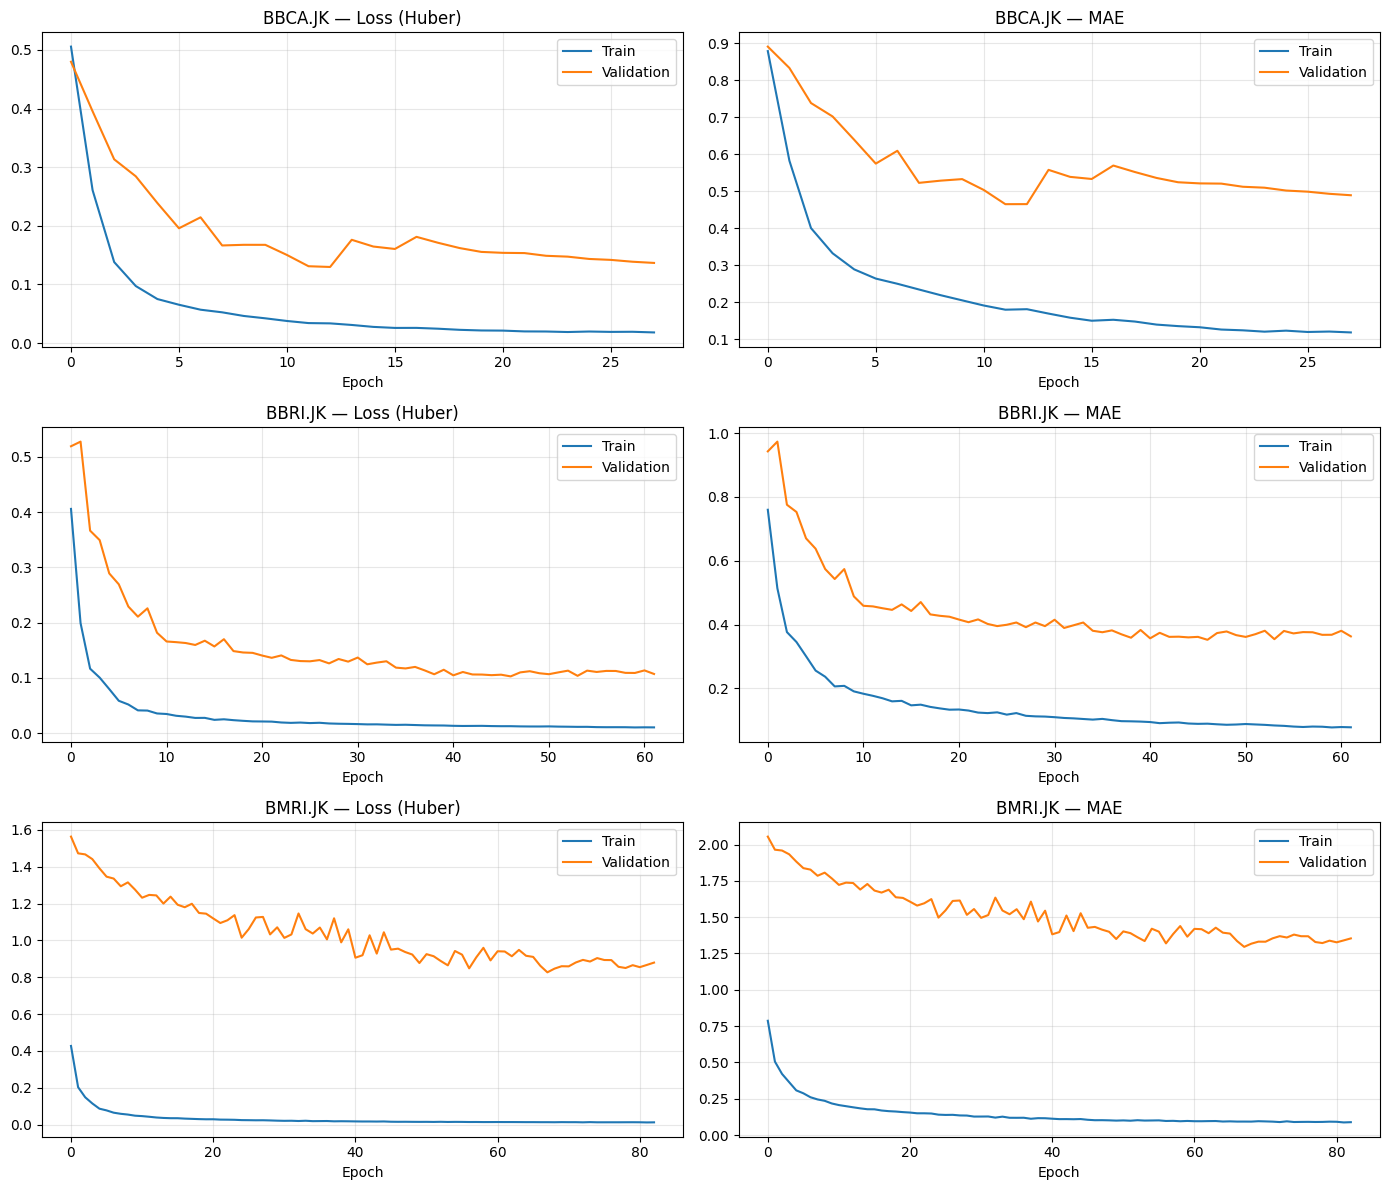

In [39]:
fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    h = histories[ticker]

    axes[i, 0].plot(h['loss'], label='Train')
    axes[i, 0].plot(h['val_loss'], label='Validation')
    axes[i, 0].set_title(f'{ticker} — Loss (Huber)')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].legend()
    axes[i, 0].grid(alpha=0.3)

    axes[i, 1].plot(h['mae'], label='Train')
    axes[i, 1].plot(h['val_mae'], label='Validation')
    axes[i, 1].set_title(f'{ticker} — MAE')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].legend()
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()


## Ensemble Prediction

In [40]:
def inverse_close(scaler, scaled_values):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

predictions = {}

for ticker in tickers:
    s      = sequences[ticker]
    scaler = scalers[ticker]
    models = ensemble_models[ticker]

    train_pred = np.mean([m.predict(s['X_train'], verbose=0).flatten() for m in models], axis=0)
    test_pred  = np.mean([m.predict(s['X_test'],  verbose=0).flatten() for m in models], axis=0)

    predictions[ticker] = {
        'y_train_true': inverse_close(scaler, s['y_train']),
        'y_train_pred': inverse_close(scaler, train_pred),
        'y_test_true' : inverse_close(scaler, s['y_test']),
        'y_test_pred' : inverse_close(scaler, test_pred),
    }


## Evaluation Metrics

In [41]:
def metrics(y_true, y_pred):
    return {
        'MAE' : mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-9))) * 100,
        'R2'  : r2_score(y_true, y_pred),
    }

rows = []
for ticker in tickers:
    p = predictions[ticker]
    rows.append({'Ticker': ticker, 'Split': 'Train', **metrics(p['y_train_true'], p['y_train_pred'])})
    rows.append({'Ticker': ticker, 'Split': 'Test',  **metrics(p['y_test_true'],  p['y_test_pred'])})

metrics_df = pd.DataFrame(rows).set_index(['Ticker', 'Split'])

(metrics_df.style
    .background_gradient(subset=['MAE', 'RMSE', 'MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2'], cmap='RdYlGn')
    .format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}%', 'R2': '{:.4f}'}))


## Prediction vs Actual

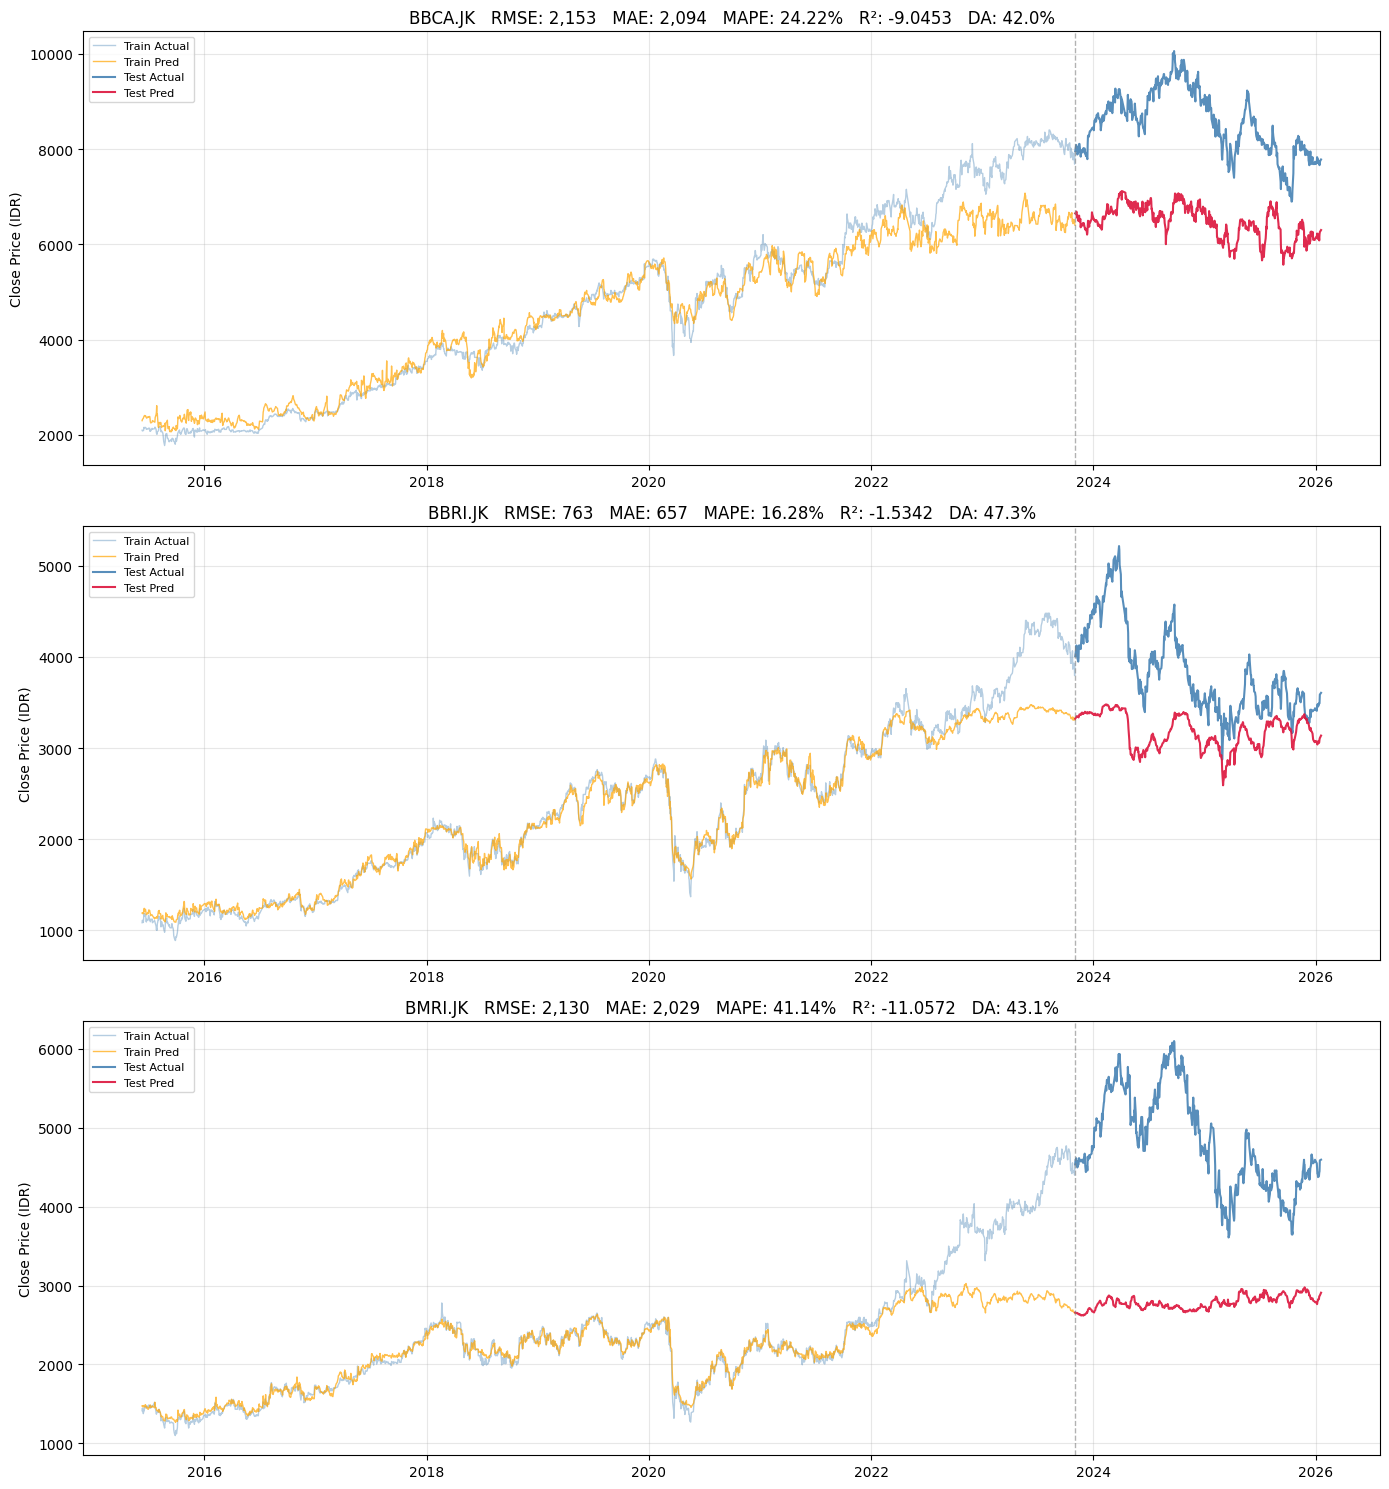

In [42]:
def directional_accuracy(y_true, y_pred):
    return (np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))).mean() * 100

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 5 * len(tickers)))

for i, ticker in enumerate(tickers):
    p     = predictions[ticker]
    ax    = axes[i]
    dates = featured_data[ticker].index
    n_tr  = len(p['y_train_true'])

    train_dates = dates[window_size : window_size + n_tr]
    test_dates  = dates[window_size + n_tr : window_size + n_tr + len(p['y_test_true'])]

    ax.plot(train_dates, p['y_train_true'], color='steelblue', alpha=0.4, lw=1,   label='Train Actual')
    ax.plot(train_dates, p['y_train_pred'], color='orange',    alpha=0.7, lw=1,   label='Train Pred')
    ax.plot(test_dates,  p['y_test_true'],  color='steelblue', alpha=0.9, lw=1.5, label='Test Actual')
    ax.plot(test_dates,  p['y_test_pred'],  color='crimson',   alpha=0.9, lw=1.5, label='Test Pred')
    ax.axvline(train_dates[-1], color='gray', linestyle='--', lw=1, alpha=0.6)

    m  = metrics(p['y_test_true'], p['y_test_pred'])
    da = directional_accuracy(p['y_test_true'], p['y_test_pred'])
    ax.set_title(
        f"{ticker}   RMSE: {m['RMSE']:,.0f}   MAE: {m['MAE']:,.0f}   "
        f"MAPE: {m['MAPE']:.2f}%   R²: {m['R2']:.4f}   DA: {da:.1f}%"
    )
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'prediction_vs_actual.png'), dpi=120, bbox_inches='tight')
plt.show()


## Test Set Zoom

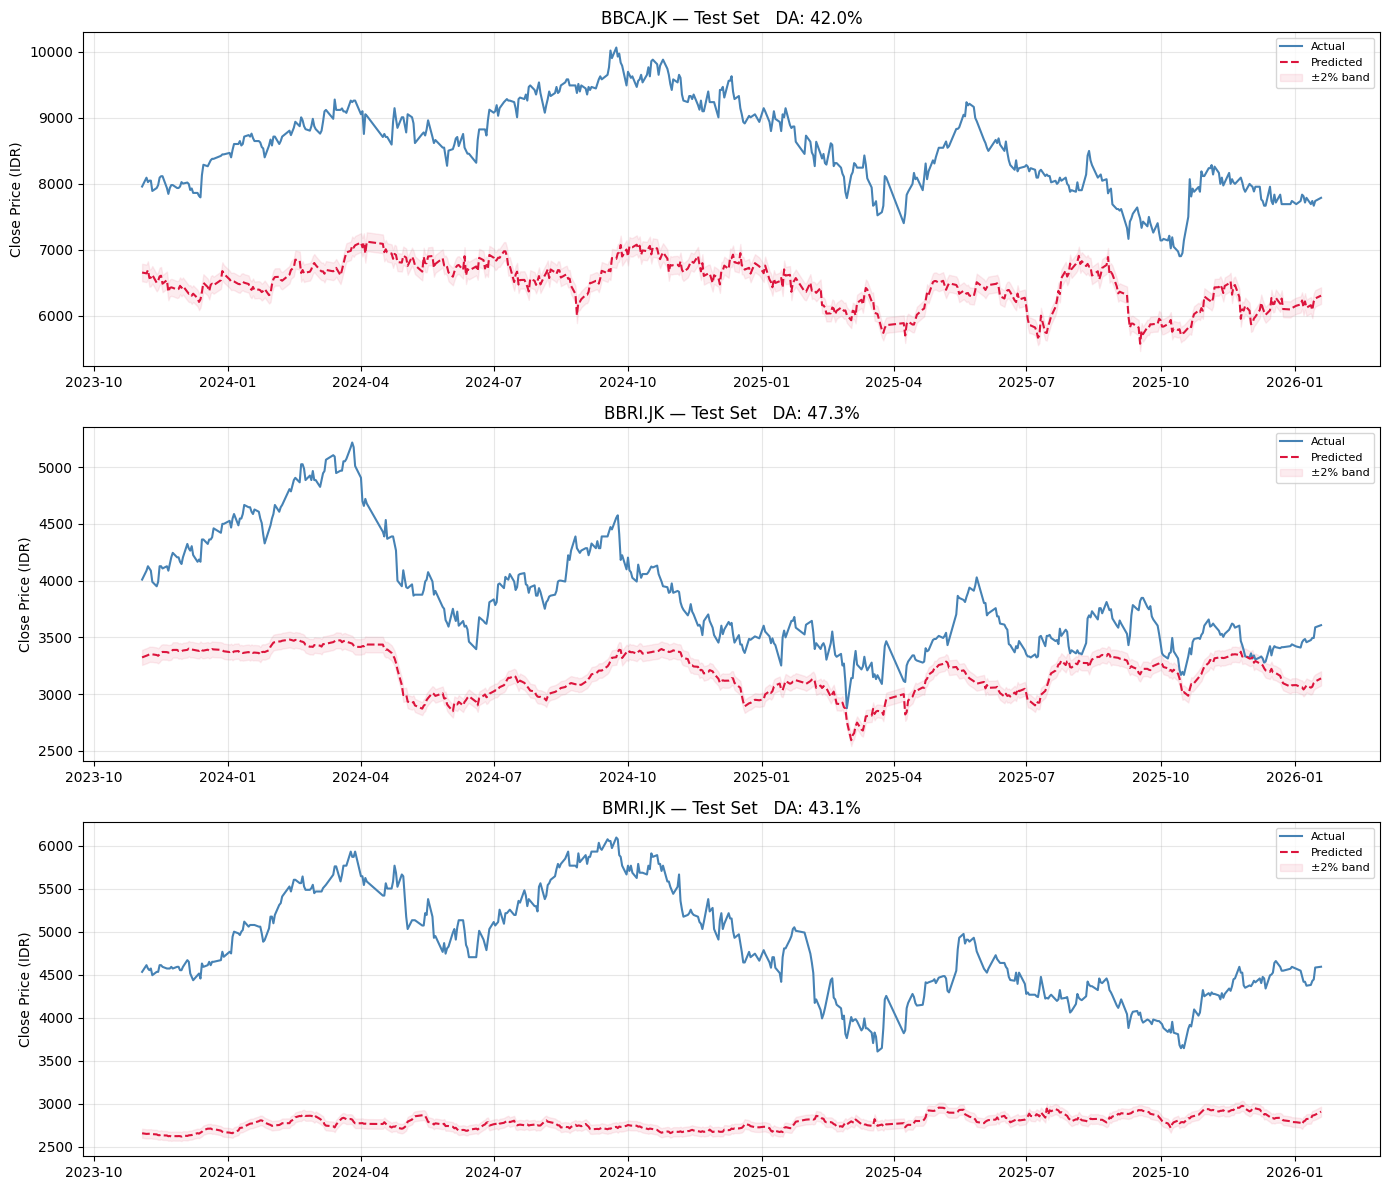

In [43]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    p     = predictions[ticker]
    ax    = axes[i]
    dates = featured_data[ticker].index
    n_tr  = len(p['y_train_true'])
    test_dates = dates[window_size + n_tr : window_size + n_tr + len(p['y_test_true'])]

    ax.plot(test_dates, p['y_test_true'], color='steelblue', lw=1.5, label='Actual')
    ax.plot(test_dates, p['y_test_pred'], color='crimson',   lw=1.5, linestyle='--', label='Predicted')
    ax.fill_between(test_dates, p['y_test_pred'] * 0.98, p['y_test_pred'] * 1.02,
                    color='crimson', alpha=0.08, label='±2% band')

    da = directional_accuracy(p['y_test_true'], p['y_test_pred'])
    ax.set_title(f'{ticker} — Test Set   DA: {da:.1f}%')
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'test_zoom.png'), dpi=120, bbox_inches='tight')
plt.show()


## Residual Analysis

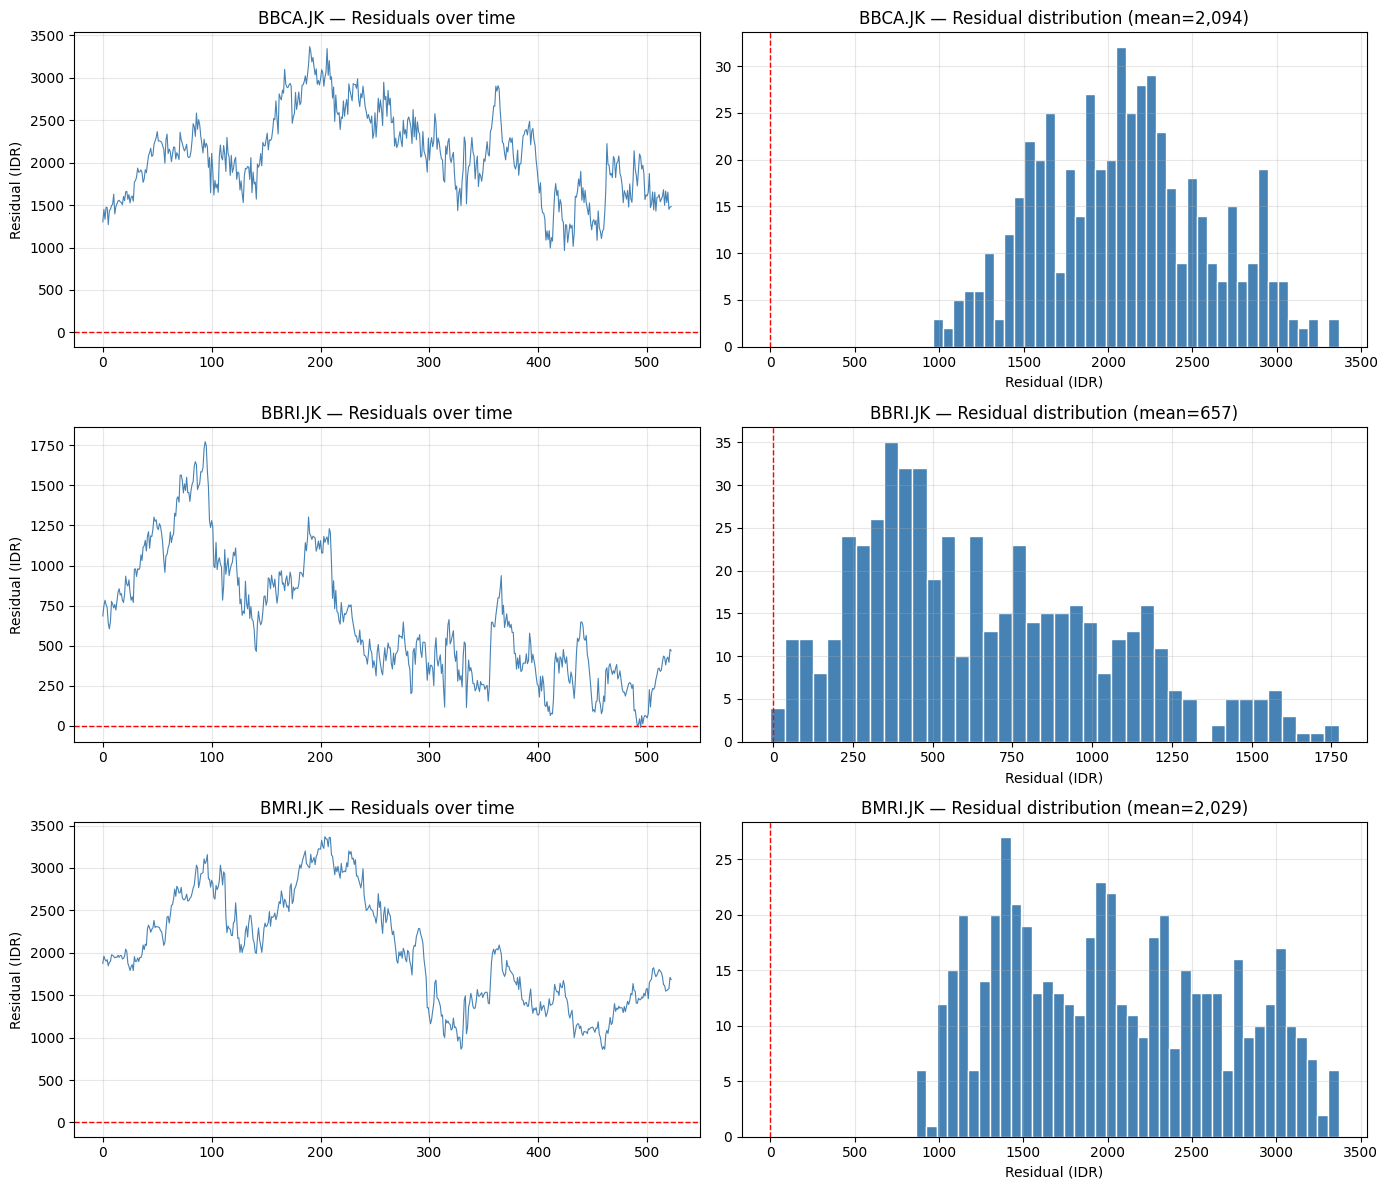

In [44]:
fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    p         = predictions[ticker]
    residuals = p['y_test_true'] - p['y_test_pred']

    axes[i, 0].plot(residuals, color='steelblue', lw=0.8)
    axes[i, 0].axhline(0, color='red', linestyle='--', lw=1)
    axes[i, 0].set_title(f'{ticker} — Residuals over time')
    axes[i, 0].set_ylabel('Residual (IDR)')
    axes[i, 0].grid(alpha=0.3)

    axes[i, 1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
    axes[i, 1].axvline(0, color='red', linestyle='--', lw=1)
    axes[i, 1].set_title(f'{ticker} — Residual distribution (mean={residuals.mean():,.0f})')
    axes[i, 1].set_xlabel('Residual (IDR)')
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'residuals.png'), dpi=120, bbox_inches='tight')
plt.show()


## Directional Accuracy

In [45]:
da_rows = []
for ticker in tickers:
    p          = predictions[ticker]
    actual_dir = np.sign(np.diff(p['y_test_true']))
    pred_dir   = np.sign(np.diff(p['y_test_pred']))

    da_rows.append({
        'Ticker'      : ticker,
        'Model DA'    : (actual_dir == pred_dir).mean() * 100,
        'Persistence' : (actual_dir == 0).mean() * 100,
    })

da_df = pd.DataFrame(da_rows).set_index('Ticker').round(2)
da_df['Beats Persistence'] = da_df['Model DA'] > da_df['Persistence']


In [46]:
(da_df.style
    .background_gradient(subset=['Model DA'], cmap='RdYlGn', vmin=40, vmax=70)
    .format({'Model DA': '{:.2f}%', 'Persistence': '{:.2f}%'}))


,Model DA,Persistence,Beats Persistence
Ticker,,,
BBCA.JK,41.95%,9.20%,True
BBRI.JK,47.32%,6.32%,True
BMRI.JK,43.10%,11.11%,True


## Ljung-Box Test (residual whiteness)

In [47]:
lb_rows = []
for ticker in tickers:
    p         = predictions[ticker]
    residuals = p['y_test_true'] - p['y_test_pred']
    lb        = acorr_ljungbox(residuals, lags=[5, 10, 20], return_df=True)
    for lag, row in lb.iterrows():
        lb_rows.append({
            'Ticker' : ticker,
            'Lag'    : int(lag),
            'LB stat': row['lb_stat'],
            'p-value': row['lb_pvalue'],
        })

lb_df = pd.DataFrame(lb_rows).set_index(['Ticker', 'Lag'])
lb_df['White noise (p>0.10)'] = lb_df['p-value'] > 0.10

(lb_df.style.format({'LB stat': '{:.4f}', 'p-value': '{:.4f}'}))


## KS-Test (feature distribution shift)

In [48]:
ks_rows = []
for ticker in tickers:
    s          = sequences[ticker]
    train_flat = s['X_train'].reshape(-1, n_features)
    test_flat  = s['X_test'].reshape(-1, n_features)

    for i, col in enumerate(active_features):
        stat, pval = ks_2samp(train_flat[:, i], test_flat[:, i])
        ks_rows.append({
            'Ticker' : ticker,
            'Feature': col,
            'KS stat': stat,
            'p-value': pval,
            'Shift'  : pval < 0.01,
        })

ks_df = pd.DataFrame(ks_rows).set_index(['Ticker', 'Feature'])
print(f'Features with significant shift (p<0.01): {ks_df["Shift"].sum()} / {len(ks_df)}')

(ks_df.style.format({'KS stat': '{:.3f}', 'p-value': '{:.4f}'}))


Features with significant shift (p<0.01): 51 / 51


## Permutation Feature Importance

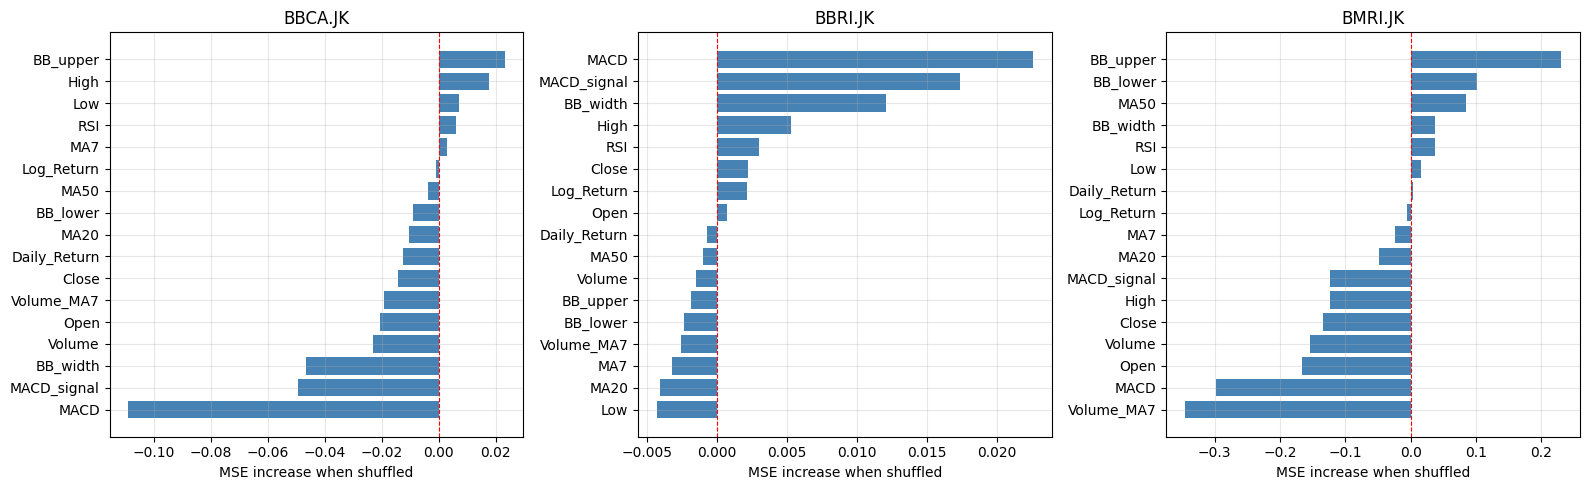

In [49]:
def permutation_importance(model, X, y, feature_names, rng):
    base_pred = model.predict(X, verbose=0).flatten()
    base_mse  = mean_squared_error(y, base_pred)

    records = []
    for i, name in enumerate(feature_names):
        X_perm = X.copy()
        flat   = X_perm[:, :, i].flatten()
        rng.shuffle(flat)
        X_perm[:, :, i] = flat.reshape(X_perm.shape[0], X_perm.shape[1])

        perm_pred = model.predict(X_perm, verbose=0).flatten()
        records.append({'Feature': name, 'Importance': mean_squared_error(y, perm_pred) - base_mse})
    return pd.DataFrame(records).sort_values('Importance', ascending=False)

importances = {}
rng = np.random.RandomState(SEED)

for ticker in tickers:
    s = sequences[ticker]
    importances[ticker] = permutation_importance(
        ensemble_models[ticker][0], s['X_test'], s['y_test'], active_features, rng,
    )

fig, axes = plt.subplots(1, len(tickers), figsize=(16, 5))
for ax, ticker in zip(axes, tickers):
    df = importances[ticker].sort_values('Importance')
    ax.barh(df['Feature'], df['Importance'], color='steelblue')
    ax.axvline(0, color='red', lw=0.8, linestyle='--')
    ax.set_title(ticker)
    ax.set_xlabel('MSE increase when shuffled')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'feature_importance.png'), dpi=120, bbox_inches='tight')
plt.show()


## 30-Day Forecast

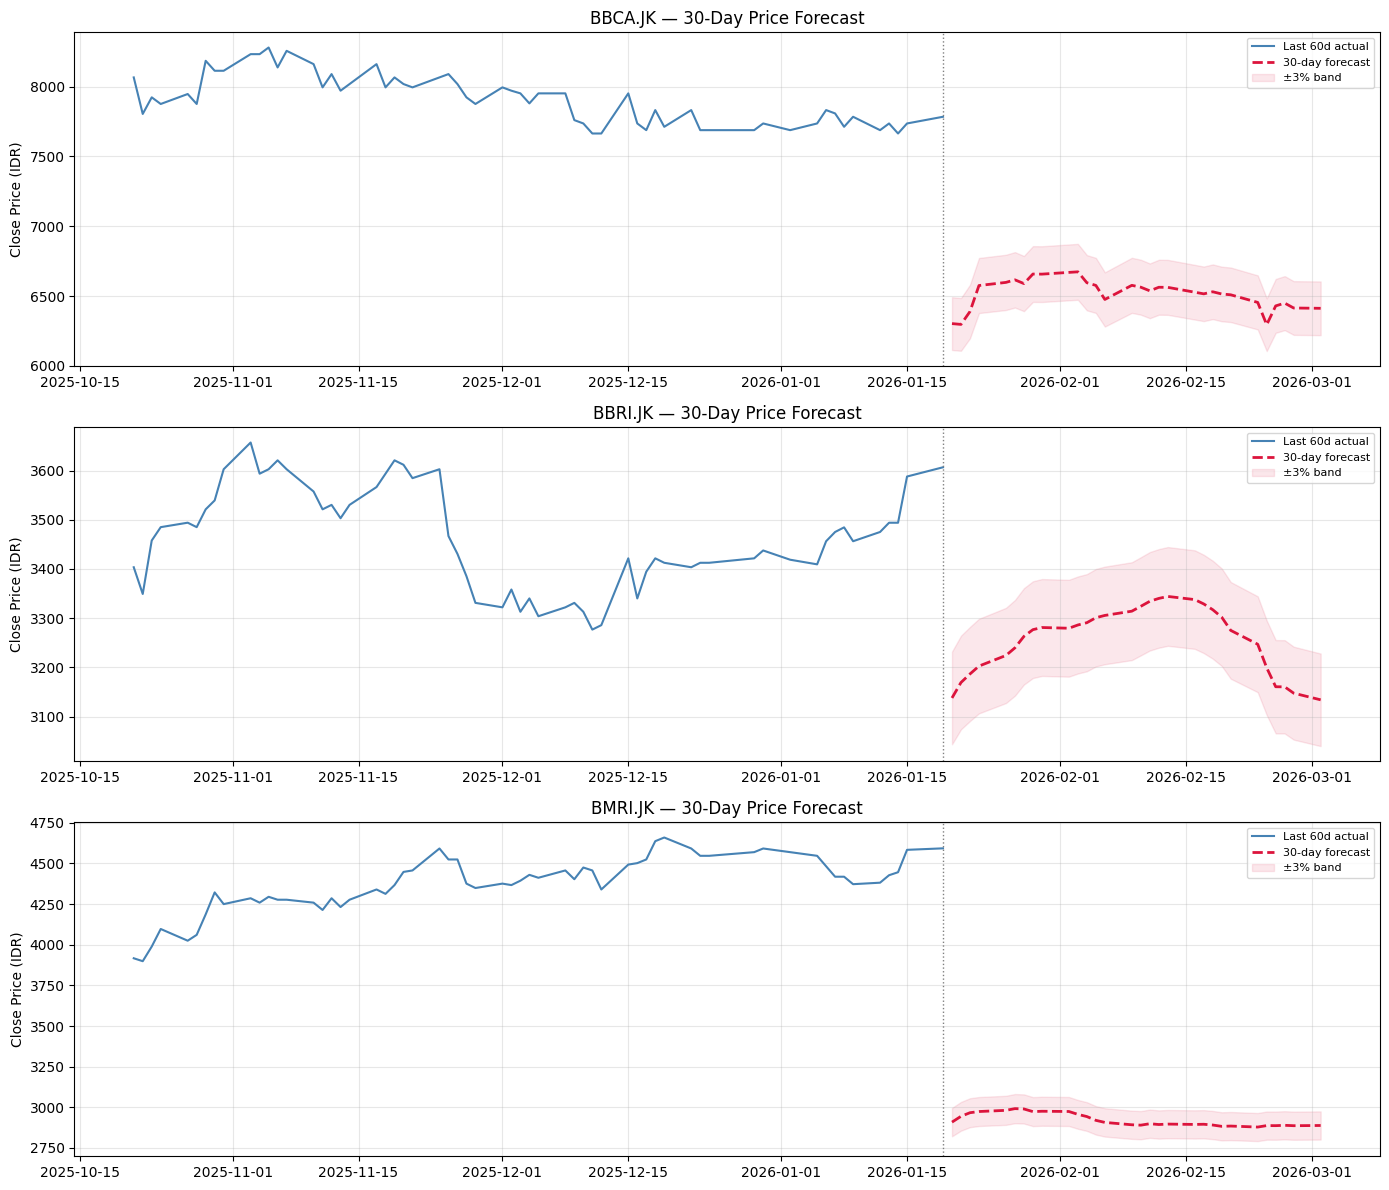

In [50]:
FORECAST_DAYS = 30

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    s           = sequences[ticker]
    scaler      = scalers[ticker]
    models_list = ensemble_models[ticker]
    ax          = axes[i]

    last_window = s['X_test'][-1].copy()
    forecast_scaled = []

    for _ in range(FORECAST_DAYS):
        preds = np.mean([m.predict(last_window[np.newaxis], verbose=0)[0, 0]
                         for m in models_list])
        forecast_scaled.append(preds)

        new_step = last_window[-1].copy()
        new_step[target_idx] = preds
        last_window = np.vstack([last_window[1:], new_step])

    forecast = inverse_close(scaler, np.array(forecast_scaled))

    last_actuals = predictions[ticker]['y_test_true'][-60:]
    last_dates   = featured_data[ticker].index[-60:]
    future_dates = pd.bdate_range(
        start=last_dates[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS,
    )

    ax.plot(last_dates,   last_actuals, color='steelblue', lw=1.5, label='Last 60d actual')
    ax.plot(future_dates, forecast,     color='crimson',   lw=2, linestyle='--',
            label=f'{FORECAST_DAYS}-day forecast')
    ax.fill_between(future_dates, forecast * 0.97, forecast * 1.03,
                    color='crimson', alpha=0.1, label='±3% band')
    ax.axvline(last_dates[-1], color='gray', linestyle=':', lw=1)
    ax.set_title(f'{ticker} — {FORECAST_DAYS}-Day Price Forecast')
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'forecast_30d.png'), dpi=120, bbox_inches='tight')
plt.show()


## Summary

In [51]:
test_metrics = metrics_df.xs('Test', level='Split')

for ticker in tickers:
    runs = mlflow.search_runs(
        experiment_names=['RaksaDana-LSTM-v2'],
        filter_string=f"tags.mlflow.runName = '{ticker}'",
        order_by=['start_time DESC'],
    )
    if runs.empty:
        continue
    with mlflow.start_run(run_id=runs.iloc[0].run_id):
        m  = test_metrics.loc[ticker]
        da = da_df.loc[ticker, 'Model DA']
        mlflow.log_metrics({
            'test_mae'  : m['MAE'],
            'test_rmse' : m['RMSE'],
            'test_mape' : m['MAPE'],
            'test_r2'   : m['R2'],
            'test_da'   : da,
        })

print('Final Test Metrics')
display(test_metrics.style.format({
    'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}%', 'R2': '{:.4f}',
}))

print('\nDirectional Accuracy')
display(da_df)

print(f'\nMLflow UI: mlflow ui --backend-store-uri sqlite:///{MLFLOW_DB}')
print(f'Experiment: RaksaDana-LSTM-v2')


Final Test Metrics


,MAE,RMSE,MAPE,R2
Ticker,,,,
BBCA.JK,"2,094.44","2,153.11",24.2246%,-9.0453
BBRI.JK,657.43,762.92,16.2828%,-1.5342
BMRI.JK,"2,028.64","2,129.89",41.1420%,-11.0572



Directional Accuracy


,Model DA,Persistence,Beats Persistence
Ticker,,,
BBCA.JK,41.95,9.20,True
BBRI.JK,47.32,6.32,True
BMRI.JK,43.10,11.11,True



MLflow UI: mlflow ui --backend-store-uri sqlite:///c:\Users\akbar\VSCode Project\RaksaDana\mlflow.db
Experiment: RaksaDana-LSTM-v2
